# Sprint 2 & 3: Modelling
---

## Table of Contents  
---

- [Introduction](#introduction)
- [Libraries](#libraries)  
- [Train/Test Split](#traintest-split)    
  - [Intialize DF for evaluation meteric](#initialize-a-dataframe-for-storing-model-evaluation-metric-results)    
- [Forecasting with Regression: Baseline Models](#forecasting-with-regression-baseline-models-)    
    - [Average/Mean Model](#average-model)    
    - [Linear Regression Model with One Feature](#linear-regression-model-with-one-feature)    
    - [Linear Regression Model with One-Hot Encoding Feature](#linear-regression-with-one-hot-encoding-feature)    
    - [Regression Model Summary](#regression-model-summary-)    
    - [Linear Regression Model with Dataset Features](#linear-regression-model-with-dataset-features)    
 
- [Sprint 3: Advanced Modeling](#sprint-3-advanced-modelling) 

  - [Forecasting with ARIMA Model](#forecasting-with-arima-model)
    - [Optimized ARIMA Hyperparameters](#optimized-arima-hyperparameters) 

  - [XG Boost](#xg-boosting-regressor)
    - [Optimized XG Boost](#optimized-xgboost-hyperparameters)

  - [ARIMA vs XGBoost](#why-does-arima-underperform-compared-to-xgboost)

  - [Forecasting with Facebook's Prophet](#forecasting-with-facebooks-prophet)

  - [Next Steps](#next-steps)

  - [Saving Results](#saving-results)


    
  

## Introduction
--- 

In this notebook we cover Baseline Modelling (Sprint 2) as well as as Advanced Modelling (Sprint 3)

# Libraries

In [33]:
# For plotly static image export
!pip install --upgrade kaleido

In [34]:
# Standard imports
import numpy as np
import pandas as pd
import itertools
import warnings
from datetime import datetime
from ipywidgets import interactive
import ipywidgets as widgets
import pickle
import os


# Loading sklearn functionality from prior lessons
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

# Important functionality for this lesson
from sklearn.model_selection import train_test_split
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif, f_regression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
#Statistical tools for model building etc
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

#plotting
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
warnings.filterwarnings('ignore')

# Importing Prophet
from prophet import Prophet



In [35]:
# Global plotting parameters
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams["axes.grid"] = True

# Brand colors dictionary
brand_colors = {
    "Denim": "#1358DB",
    "Supernova": "#FFCF00",
    # "Black": "#000000",
    # "Dark Blue": "#101D42",
    # "White": "#FFFFFF",
    "Dark Gray": "#6F6F6F",
    # "Light Gray 1": "#F6F6F4",
    "Light Gray 2": "#ADBDCC"
}

# Create a matplotlib colormap
brand_cmap = plt.cm.colors.ListedColormap(list(brand_colors.values()))
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=brand_colors.values())

"""
Note: Suppressing warnings is generally not recommended. 
Warnings are being ignored in this notebook to prevent unnecessary clutter
and improve readability while working through the lesson
"""
filterwarnings(action='ignore')

# Train/Test Split

In order to properly evaluate our models, we need to isolate our Train and Test set. In traditional machine learning  modeling, we generally take random samples of data points and have them randomly assigned to the corresponding sets. **This is not possible in Time Series because there is an order to time that we need to preserve**. In order to keep the sequential order of our data, we generally take a proportion of the most recent data points, and assign them to the Test set. We use the remainder points as our Train set.

First lets start by loading our data, we will use the daily average sampled data that we created in the previous notebook for preprocessing

In [36]:

power_df_monthly = pd.read_csv(r"C:\Users\karni\OneDrive\Desktop\GitHub\BrainStation_CapstoneProject\data\power_weather_monthly.csv",index_col='Datetime')

power_df_monthly.head()

,Energy Consumed by Household (Watt-hour),Sub_metering_4 (watt-hours of active energy),Reactive Energy Consumed by Household (Watt-hour),Voltage (volts),Global_intensity (amperes),Sub_metering_1 (watt-hours of active energy),Sub_metering_2 (watt-hours of active energy),Sub_metering_3 (watt-hours of active energy),temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),surface_pressure (hPa),cloudcover (%),windspeed_10m (km/h),windgusts_10m (km/h),winddirection_10m (degrees),shortwave_radiation (W/m²),direct_radiation (W/m²),diffuse_radiation (W/m²)
Datetime,,,,,,,,,,,,,,,,,,,,
2006-12-01,31.688252,20.815071,2.189763,241.441125,8.029956,1.248636,2.214987,7.409558,2.665667,89.373203,1.035962,-1.077252,1020.453060,69.210094,12.331461,23.786715,122.629084,34.024386,14.111747,19.912639
2007-01-01,25.767232,15.343714,2.211268,240.905101,6.546915,1.264237,1.775931,7.383351,7.207161,84.024638,4.577192,3.423857,1010.176016,82.074769,17.715948,35.031811,211.768246,38.132655,15.181784,22.950871
2007-02-01,23.351392,13.865257,1.893946,240.519390,5.914569,1.180217,1.602361,6.703557,7.549305,82.832249,4.651629,3.992242,999.810829,79.073664,15.637397,31.425021,194.193422,73.579543,38.948361,34.631182
2007-03-01,21.977117,11.764254,1.912447,240.513469,5.572979,1.361343,2.346872,6.504648,7.257748,79.442310,3.707103,3.849526,1005.630479,59.874198,13.452050,27.374541,215.718411,124.956769,71.833233,53.123536
2007-04-01,14.853149,8.013774,1.979631,239.400026,3.825676,1.065886,0.973149,4.800339,13.788870,68.136852,7.520775,11.847011,1008.825148,30.560534,10.867634,22.397924,100.470444,248.593624,193.129412,55.464212


In [37]:
power_df_monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 2006-12-01 to 2010-11-01
Data columns (total 20 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Energy Consumed by Household (Watt-hour)           48 non-null     float64
 1   Sub_metering_4 (watt-hours of active energy)       48 non-null     float64
 2   Reactive Energy Consumed by Household (Watt-hour)  48 non-null     float64
 3   Voltage (volts)                                    48 non-null     float64
 4   Global_intensity (amperes)                         48 non-null     float64
 5   Sub_metering_1 (watt-hours of active energy)       48 non-null     float64
 6   Sub_metering_2 (watt-hours of active energy)       48 non-null     float64
 7   Sub_metering_3 (watt-hours of active energy)       48 non-null     float64
 8   temperature_2m (°C)                                48 non-null     float64
 9   

In [38]:
# Time Series Split (test set = most recent 25% of data)

# finding the row number equivalent to 75% of the data
cutoff = int(len(power_df_monthly) * 0.75)
cutoff_date = power_df_monthly.index.sort_values()[cutoff]
print(f"Cutoff at: {cutoff_date}")

# extract train and test indices
dates_train = power_df_monthly.index[power_df_monthly.index <= cutoff_date]
date_train = pd.to_datetime(dates_train) # changing to time stamp
dates_test = power_df_monthly.index[power_df_monthly.index > cutoff_date]
date_test = pd.to_datetime(dates_test) # changing to time stamp

# extract dimensions
print(f"Training Set: {len(dates_train)} days")
print(f"Test Set: {len(dates_test)} days")

Cutoff at: 2009-12-01
Training Set: 37 days
Test Set: 11 days


In [39]:
# Extracting the target variable Energy Consumed by Household (Watt-hour)
y_train = power_df_monthly['Energy Consumed by Household (Watt-hour)'].loc[dates_train]
y_test = power_df_monthly['Energy Consumed by Household (Watt-hour)'].loc[dates_test]

## Initialize a dataframe for storing model evaluation metric results


In [40]:
summary_df = pd.DataFrame(columns=["Train_MAE", "Test_MAE", "Train_MAPE", "Test_MAPE"])

# <a id='toc5_'></a>Forecasting with Regression: Baseline Models [&#8593;](#toc0_)



In this section I will build 3 different models, starting from a naive simple average model, to a multiple linear regression model with one-hot encoded variables to represent the different months

At every iteration I will fit the model, visualize it against the original data and evaluate the predictions. I will not apply any regularization for now, we will use Lasso, Ridge, in Sprint 3 for of regression model.


Here is an overview of the models that I  will build:

1. **Average Model:** $y = mean(y)$
  
2. **Linear Model with One Feature:** $y = \beta_0 + \beta_1\text{DaysFromStart}$

3. **Linear Model with Dummy Variables:** $y = \beta_0 + \beta_1\text{DaysFromStart} + \beta_2\text{January} + \beta_3\text{February} + .... + \beta_{13}\text{December}$



As we go through the model building process we will use the following table to keep track of our model performance metrics:

## Average Model

We will start with a  model of simply guessing the mean of the data. We do not expect this to perform well, however it serves as a good starting point to extract some baseline evaluation metrics that we will try to improve further down.

In [41]:
# Predict

train_mean = y_train.mean()

training_size = len(dates_train)
test_size = len(dates_test)

mean_pred_train = np.full((training_size, 1), train_mean)
mean_pred_test = np.full((test_size, 1), train_mean) 

In [42]:
# Drop NaNs from target and predictions for fair comparison
train_mask = ~y_train.isna()
test_mask = ~y_test.isna()

summary_df.loc['Mean'] = [
    mean_absolute_error(
        y_train[train_mask],
        mean_pred_train.flatten()[train_mask.values]
    ),
    mean_absolute_error(
        y_test[test_mask],
        mean_pred_test.flatten()[test_mask.values]
    ),
    mean_absolute_percentage_error(
        y_train[train_mask],
        mean_pred_train.flatten()[train_mask.values]
    ),
    mean_absolute_percentage_error(
        y_test[test_mask],
        mean_pred_test.flatten()[test_mask.values]
    )
]

summary_df

,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE
Mean,4.034347,3.101882,0.292217,0.215832


In [43]:
# Plotting the results

fig = go.Figure()

# Original time series
fig.add_trace(go.Scatter(
    x=power_df_monthly.index,
    y=power_df_monthly['Energy Consumed by Household (Watt-hour)'],
    mode='lines',
    name='data',
    line=dict(color='grey')
))

# Train predictions
fig.add_trace(go.Scatter(
    x=dates_train,
    y=mean_pred_train.flatten(),
    mode='lines',
    name='train',
    line=dict(color='green')
))

# Test predictions
fig.add_trace(go.Scatter(
    x=dates_test,
    y=mean_pred_test.flatten(),
    mode='lines',
    name='test',
    line=dict(color='green', dash='dash')
))

# Set x-axis ticks for better readability
labels = pd.to_datetime(power_df_monthly.index).strftime('%b-%Y')
step = max(1, len(labels) // 10)
fig.update_layout(
    title='Average Model Performance',
    yaxis_title='Watt-hour',
    xaxis_title='Date',
    legend_title='Legend',
    xaxis=dict(
        tickmode='array',
        tickvals=power_df_monthly.index[::step],
        ticktext=labels[::step],
        tickangle=45
    ),
    width=900,
    height=400
)



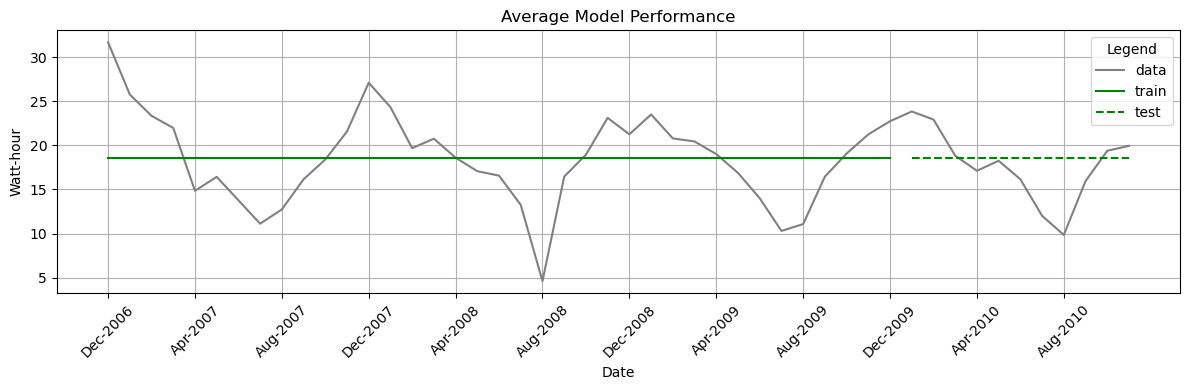

In [44]:
plt.figure()

# Original time series
plt.plot(power_df_monthly.index, power_df_monthly['Energy Consumed by Household (Watt-hour)'], color='grey', label='data')

# Train predictions
plt.plot(dates_train, mean_pred_train.flatten(), color='green', label='train')

# Test predictions
plt.plot(dates_test, mean_pred_test.flatten(), color='green', linestyle='--', label='test')

plt.title('Average Model Performance')
plt.ylabel('Watt-hour')
plt.xlabel('Date')
plt.legend(title='Legend')

# Format x-axis as month-year and reduce number of ticks
locs = plt.gca().get_xticks()
labels = pd.to_datetime(power_df_monthly.index).strftime('%b-%Y')
step = max(1, len(labels) // 10)
plt.xticks(ticks=range(0, len(labels), step), labels=labels[::step], rotation=45)

plt.tight_layout()
plt.show()


## Linear Regression Model with One Feature

We will now proceed by adding our first freature: `days_from_start` 

In [45]:
first_day = power_df_monthly.index.min() # We get a string here
first_day = pd.to_datetime(first_day) # cahnging to time stamp
print(first_day)

2006-12-01 00:00:00


In [46]:
# Feature Engineering

# Ensure first_day is a Timestamp
first_day = pd.to_datetime(power_df_monthly.index.min())

# Ensure dates_train and dates_test are DatetimeIndex
dates_train_dt = pd.to_datetime(dates_train)
dates_test_dt = pd.to_datetime(dates_test)

# Create a numerical X feature that encodes the days from the start of the data
X_train = pd.DataFrame({"days_from_start": (dates_train_dt - first_day).days}, index=dates_train)
X_test = pd.DataFrame({"days_from_start": (dates_test_dt - first_day).days}, index=dates_test)

X_train.head()

,days_from_start
Datetime,
2006-12-01,0
2007-01-01,31
2007-02-01,62
2007-03-01,90
2007-04-01,121


In [47]:
y_train.head()

Datetime
2006-12-01    31.688252
2007-01-01    25.767232
2007-02-01    23.351392
2007-03-01    21.977117
2007-04-01    14.853149
Name: Energy Consumed by Household (Watt-hour), dtype: float64

In [48]:
# Fit
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict
linreg_pred_train = linreg.predict(X_train)
linreg_pred_test = linreg.predict(X_test)

In [49]:
# Evaluate

summary_df.loc['linreg'] = [
    mean_absolute_error(y_train, linreg_pred_train),
    mean_absolute_error(y_test, linreg_pred_test),
    mean_absolute_percentage_error(y_train, linreg_pred_train),
    mean_absolute_percentage_error(y_test, linreg_pred_test)
]


fig = go.Figure()

# Original time series
fig.add_trace(go.Scatter(
    x=power_df_monthly.index,
    y=power_df_monthly['Energy Consumed by Household (Watt-hour)'],
    mode='lines',
    name='data',
    line=dict(color='grey')
))

# Train predictions
fig.add_trace(go.Scatter(
    x=dates_train,
    y=linreg_pred_train,
    mode='lines',
    name='train',
    line=dict(color='green')
))

# Test predictions
fig.add_trace(go.Scatter(
    x=dates_test,
    y=linreg_pred_test,
    mode='lines',
    name='test',
    line=dict(color='green', dash='dash')
))

# Set x-axis ticks for better readability
labels = pd.to_datetime(power_df_monthly.index).strftime('%b-%Y')
step = max(1, len(labels) // 10)
fig.update_layout(
    title='Linear Regression Model Performance',
    yaxis_title='Watt-hour',
    xaxis_title='Date',
    legend_title='Legend',
    xaxis=dict(
        tickmode='array',
        tickvals=power_df_monthly.index[::step],
        ticktext=labels[::step],
        tickangle=45
    ),
    width=900,
    height=400
)

fig.show()


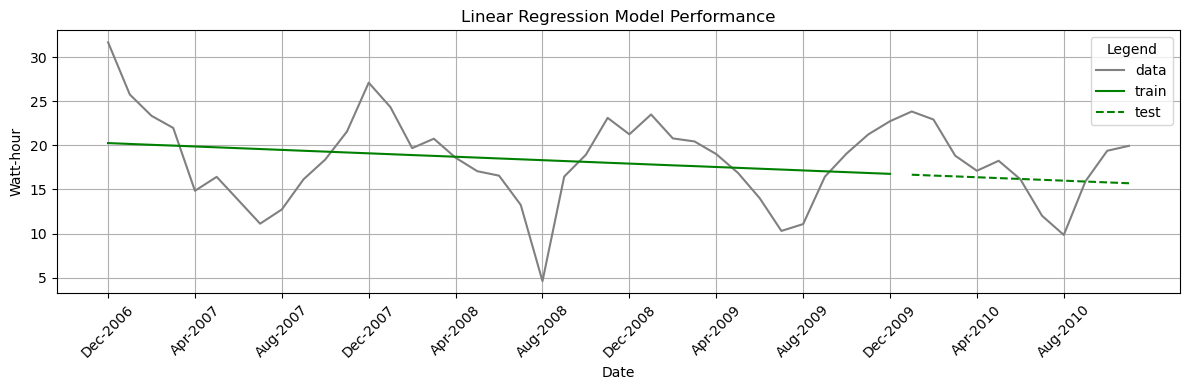

In [50]:
plt.figure(figsize=(12, 4))

# Original time series
plt.plot(power_df_monthly.index, power_df_monthly['Energy Consumed by Household (Watt-hour)'], color='grey', label='data')

# Train predictions
plt.plot(dates_train, linreg_pred_train, color='green', label='train')

# Test predictions
plt.plot(dates_test, linreg_pred_test, color='green', linestyle='--', label='test')

plt.title('Linear Regression Model Performance')
plt.ylabel('Watt-hour')
plt.xlabel('Date')
plt.legend(title='Legend')

# Format x-axis as month-year and reduce number of ticks
labels = pd.to_datetime(power_df_monthly.index).strftime('%b-%Y')
step = max(1, len(labels) // 10)
plt.xticks(ticks=range(0, len(labels), step), labels=labels[::step], rotation=45)

plt.tight_layout()
plt.show()


In [51]:
summary_df

,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE
Mean,4.034347,3.101882,0.292217,0.215832
linreg,4.077902,3.336767,0.294629,0.201769


This looks slightly better  in  our visual intuition.  As you might expect, our model captures the overal trend of the data as a straight line with an downward slope.  Our evaluation metrics indicate that our model has an overall error of 4.07	Watt-hour on average (MAE) for training data, but a lower error rate of 3.33 Watt-hour for test data.  



## <a id='toc5_2_'></a>Linear Regression with One-Hot Encoding Feature [&#8593;](#toc0_)

In [52]:
# Feature Engineering for One-Hot Encoding

# instantiate encoder
ohe = OneHotEncoder(sparse_output=False, dtype=int)

# extract month names from index (convert to datetime if needed)
months_train = pd.to_datetime(X_train.index).month_name().values.reshape(-1, 1)
months_test = pd.to_datetime(X_test.index).month_name().values.reshape(-1, 1)

# fit on train set, transform train and test
ohe_months_train = ohe.fit_transform(months_train)
ohe_months_test = ohe.transform(months_test)

# convert data back into a dataframe
ohe_train_df = pd.DataFrame(ohe_months_train, columns=ohe.get_feature_names_out(), index=X_train.index)
ohe_test_df = pd.DataFrame(ohe_months_test, columns=ohe.get_feature_names_out(), index=X_test.index)

# concatenate days_from_start and month dummies
X_train_ohe = pd.concat([X_train, ohe_train_df], axis=1)
X_test_ohe = pd.concat([X_test, ohe_test_df], axis=1)


In [53]:
X_train_ohe.head()

,days_from_start,x0_April,x0_August,x0_December,x0_February,x0_January,x0_July,x0_June,x0_March,x0_May,x0_November,x0_October,x0_September
Datetime,,,,,,,,,,,,,
2006-12-01,0,0,0,1,0,0,0,0,0,0,0,0,0
2007-01-01,31,0,0,0,0,1,0,0,0,0,0,0,0
2007-02-01,62,0,0,0,1,0,0,0,0,0,0,0,0
2007-03-01,90,0,0,0,0,0,0,0,1,0,0,0,0
2007-04-01,121,1,0,0,0,0,0,0,0,0,0,0,0


In [54]:
X_train_ohe.shape

(37, 13)

In [55]:
# Fit
linreg_ohe = LinearRegression()
linreg_ohe.fit(X_train_ohe, y_train)

# Predict
ohe_pred_train = linreg_ohe.predict(X_train_ohe)
ohe_pred_test = linreg_ohe.predict(X_test_ohe)

In [56]:
# Evaluate

summary_df.loc['linreg_ohe'] = [
    mean_absolute_error(y_train, ohe_pred_train),
    mean_absolute_error(y_test, ohe_pred_test),
    mean_absolute_percentage_error(y_train, ohe_pred_train),
    mean_absolute_percentage_error(y_test, ohe_pred_test)
]

summary_df

,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE
Mean,4.034347,3.101882,0.292217,0.215832
linreg,4.077902,3.336767,0.294629,0.201769
linreg_ohe,1.315639,1.717609,0.095819,0.104766


In [57]:
# Original time series
import plotly.graph_objs as go
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=power_df_monthly.index,
    y=power_df_monthly['Energy Consumed by Household (Watt-hour)'],
    mode='lines',
    name='data',
    line=dict(color='grey')
))

# Train predictions
fig.add_trace(go.Scatter(
    x=dates_train,
    y=ohe_pred_train,
    mode='lines',
    name='train',
    line=dict(color='green')
))

# Test predictions
fig.add_trace(go.Scatter(
    x=dates_test,
    y=ohe_pred_test,
    mode='lines',
    name='test',
    line=dict(color='green', dash='dash')
))

fig.update_layout(
    title='Linear Regression with One Hot Encoding Model Performance',
    yaxis_title='Watt-hour',
    xaxis_title='Date',
    legend_title='Legend'
)

fig.show()

We can see that our model is now  able to capture the cyclic nature of  the energy consumption data, which was not possible with the simple linear regression model that only used the days from the start of the data as a feature. The one-hot encoding of the month allows the model to learn seasonal patterns in energy consumption, leading to improved predictions.

In [58]:
summary_df

,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE
Mean,4.034347,3.101882,0.292217,0.215832
linreg,4.077902,3.336767,0.294629,0.201769
linreg_ohe,1.315639,1.717609,0.095819,0.104766


When predicting on unseen data, our model was on average ~1.7 Watt hour away from the true monthly Energy Consumption. MAPE provides a relative measure of error by dividing the errors by the original values of the time series, and shows that our model is on average ~10% away when making predictions, which is better than the previous models of ~20%.

## <a id='toc5_4_'></a>Regression Model Summary [&#8593;](#toc0_)

Overall we can see that the third model (linear regression with one hot encoded month variables) has performed the best out of the 3. This is clear both by visual inspection, and by looking at the evaluation metrics below.

Focusing on the test set for the fourth model:

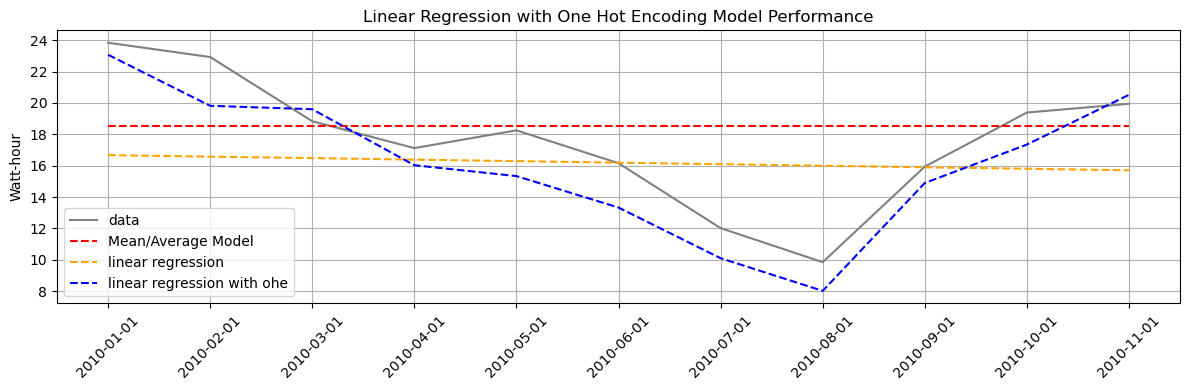

In [59]:
plt.figure()


# Original time series (test set)
plt.plot(y_test, color='grey', label="data")

# Model performance
plt.plot(dates_test, mean_pred_test, color='red', ls="--", label="Mean/Average Model")
plt.plot(dates_test, linreg_pred_test, color='orange', ls="--", label="linear regression")
plt.plot(dates_test, ohe_pred_test, color='blue', ls="--", label="linear regression with ohe")

plt.ylabel("Watt-hour")
plt.title("Linear Regression with One Hot Encoding Model Performance")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Lets  now create a model that takes into account the original features of the dataset, such as temperature, humidity, and wind speed, to predict the energy consumption of the household. This will allow us to see if we can improve our model's performance by incorporating these additional features.


4. **Linear Model with Features:** $y = \beta_0 + \beta_1\text{X1} + \beta_2\text{X2} + \beta_3\text{X3} + .... + \beta_{19}\text{X19}$
  
  where, X represents the features we have in the dataset for power df

## Linear Regression model with Dataset Features

We will be using a linear regression  with data set model  to forecast the Energy Consumption 

In [60]:
power_df_monthly.head()

,Energy Consumed by Household (Watt-hour),Sub_metering_4 (watt-hours of active energy),Reactive Energy Consumed by Household (Watt-hour),Voltage (volts),Global_intensity (amperes),Sub_metering_1 (watt-hours of active energy),Sub_metering_2 (watt-hours of active energy),Sub_metering_3 (watt-hours of active energy),temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),surface_pressure (hPa),cloudcover (%),windspeed_10m (km/h),windgusts_10m (km/h),winddirection_10m (degrees),shortwave_radiation (W/m²),direct_radiation (W/m²),diffuse_radiation (W/m²)
Datetime,,,,,,,,,,,,,,,,,,,,
2006-12-01,31.688252,20.815071,2.189763,241.441125,8.029956,1.248636,2.214987,7.409558,2.665667,89.373203,1.035962,-1.077252,1020.453060,69.210094,12.331461,23.786715,122.629084,34.024386,14.111747,19.912639
2007-01-01,25.767232,15.343714,2.211268,240.905101,6.546915,1.264237,1.775931,7.383351,7.207161,84.024638,4.577192,3.423857,1010.176016,82.074769,17.715948,35.031811,211.768246,38.132655,15.181784,22.950871
2007-02-01,23.351392,13.865257,1.893946,240.519390,5.914569,1.180217,1.602361,6.703557,7.549305,82.832249,4.651629,3.992242,999.810829,79.073664,15.637397,31.425021,194.193422,73.579543,38.948361,34.631182
2007-03-01,21.977117,11.764254,1.912447,240.513469,5.572979,1.361343,2.346872,6.504648,7.257748,79.442310,3.707103,3.849526,1005.630479,59.874198,13.452050,27.374541,215.718411,124.956769,71.833233,53.123536
2007-04-01,14.853149,8.013774,1.979631,239.400026,3.825676,1.065886,0.973149,4.800339,13.788870,68.136852,7.520775,11.847011,1008.825148,30.560534,10.867634,22.397924,100.470444,248.593624,193.129412,55.464212


In [61]:
# Pull out the X and y
X = power_df_monthly.drop('Energy Consumed by Household (Watt-hour)', axis=1)
y = power_df_monthly["Energy Consumed by Household (Watt-hour)"].copy()

In [62]:
X.head()

,Sub_metering_4 (watt-hours of active energy),Reactive Energy Consumed by Household (Watt-hour),Voltage (volts),Global_intensity (amperes),Sub_metering_1 (watt-hours of active energy),Sub_metering_2 (watt-hours of active energy),Sub_metering_3 (watt-hours of active energy),temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),surface_pressure (hPa),cloudcover (%),windspeed_10m (km/h),windgusts_10m (km/h),winddirection_10m (degrees),shortwave_radiation (W/m²),direct_radiation (W/m²),diffuse_radiation (W/m²)
Datetime,,,,,,,,,,,,,,,,,,,
2006-12-01,20.815071,2.189763,241.441125,8.029956,1.248636,2.214987,7.409558,2.665667,89.373203,1.035962,-1.077252,1020.453060,69.210094,12.331461,23.786715,122.629084,34.024386,14.111747,19.912639
2007-01-01,15.343714,2.211268,240.905101,6.546915,1.264237,1.775931,7.383351,7.207161,84.024638,4.577192,3.423857,1010.176016,82.074769,17.715948,35.031811,211.768246,38.132655,15.181784,22.950871
2007-02-01,13.865257,1.893946,240.519390,5.914569,1.180217,1.602361,6.703557,7.549305,82.832249,4.651629,3.992242,999.810829,79.073664,15.637397,31.425021,194.193422,73.579543,38.948361,34.631182
2007-03-01,11.764254,1.912447,240.513469,5.572979,1.361343,2.346872,6.504648,7.257748,79.442310,3.707103,3.849526,1005.630479,59.874198,13.452050,27.374541,215.718411,124.956769,71.833233,53.123536
2007-04-01,8.013774,1.979631,239.400026,3.825676,1.065886,0.973149,4.800339,13.788870,68.136852,7.520775,11.847011,1008.825148,30.560534,10.867634,22.397924,100.470444,248.593624,193.129412,55.464212


In [63]:
y.head()

Datetime
2006-12-01    31.688252
2007-01-01    25.767232
2007-02-01    23.351392
2007-03-01    21.977117
2007-04-01    14.853149
Name: Energy Consumed by Household (Watt-hour), dtype: float64

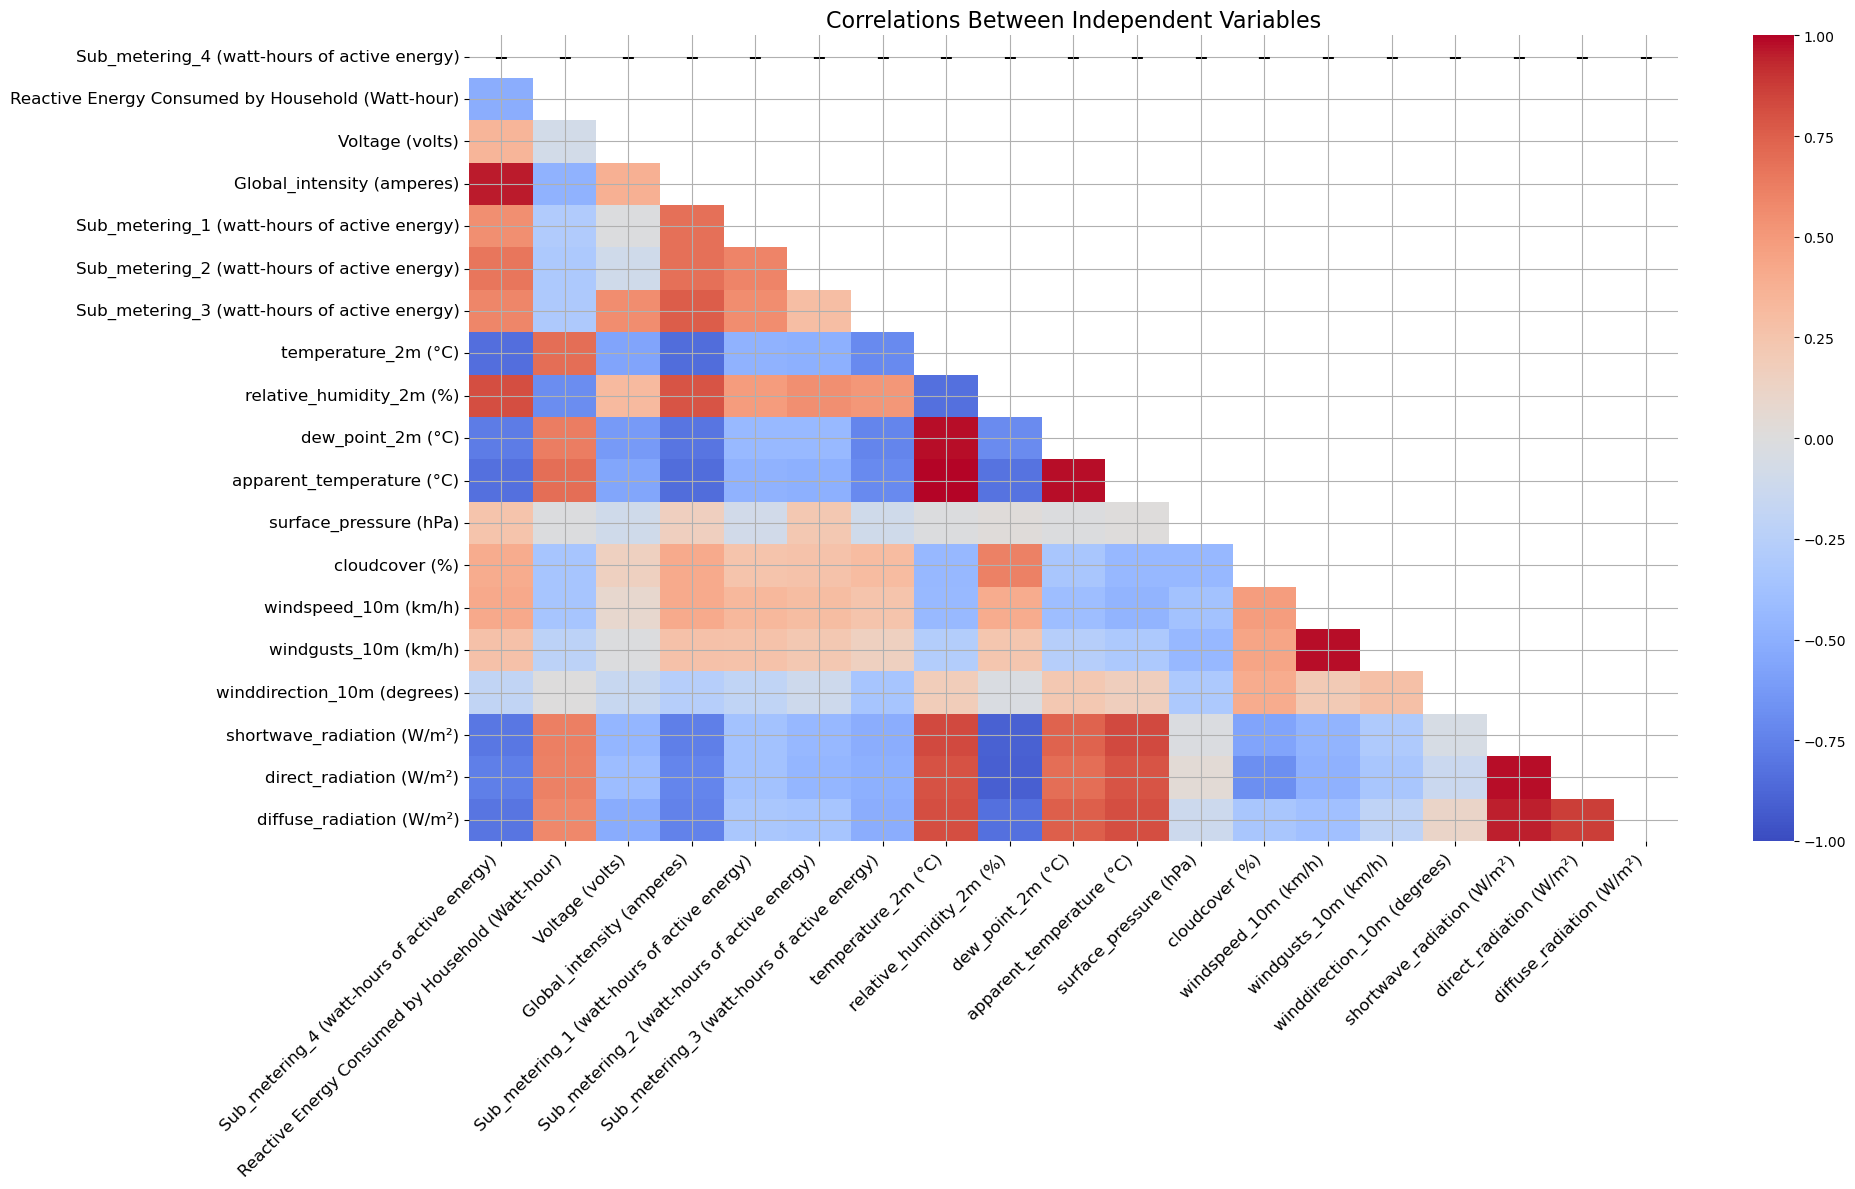

In [68]:
# Calculate the correlation matrix
corr_df = X.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_df, dtype=bool))

plt.figure(figsize=(20, 12))
sns.heatmap(
    corr_df.round(2), 
    annot=True, 
    annot_kws={"size": 12, "weight": "bold", "color": "black"},
    vmax=1, 
    vmin=-1, 
    center=0, 
    cmap="coolwarm", 
    mask=mask,
    fmt=".2f"
)
plt.title("Correlations Between Independent Variables", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

**Note: I dont why my correlation heatmap matrix is not showing any numeric values. I tried everything, so I use a table to see the actual values**

In [69]:
X.corr().round(2)

,Sub_metering_4 (watt-hours of active energy),Reactive Energy Consumed by Household (Watt-hour),Voltage (volts),Global_intensity (amperes),Sub_metering_1 (watt-hours of active energy),Sub_metering_2 (watt-hours of active energy),Sub_metering_3 (watt-hours of active energy),temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),surface_pressure (hPa),cloudcover (%),windspeed_10m (km/h),windgusts_10m (km/h),winddirection_10m (degrees),shortwave_radiation (W/m²),direct_radiation (W/m²),diffuse_radiation (W/m²)
Sub_metering_4 (watt-hours of active energy),1.00,-0.51,0.35,0.96,0.55,0.66,0.59,-0.84,0.82,-0.78,-0.83,0.25,0.40,0.42,0.27,-0.19,-0.80,-0.76,-0.81
Reactive Energy Consumed by Household (Watt-hour),-0.51,1.00,-0.08,-0.48,-0.29,-0.32,-0.31,0.69,-0.69,0.63,0.69,-0.01,-0.35,-0.35,-0.22,-0.00,0.62,0.61,0.58
Voltage (volts),0.35,-0.08,1.00,0.38,-0.01,-0.10,0.56,-0.57,0.32,-0.62,-0.56,-0.10,0.15,0.08,-0.01,-0.15,-0.46,-0.41,-0.52
Global_intensity (amperes),0.96,-0.48,0.38,1.00,0.68,0.68,0.76,-0.85,0.79,-0.81,-0.85,0.16,0.41,0.41,0.27,-0.26,-0.76,-0.73,-0.75
Sub_metering_1 (watt-hours of active energy),0.55,-0.29,-0.01,0.68,1.00,0.60,0.56,-0.48,0.49,-0.43,-0.48,-0.09,0.25,0.33,0.26,-0.20,-0.37,-0.37,-0.33
Sub_metering_2 (watt-hours of active energy),0.66,-0.32,-0.10,0.68,0.60,1.00,0.29,-0.50,0.55,-0.43,-0.50,0.22,0.26,0.30,0.22,-0.11,-0.44,-0.46,-0.35
Sub_metering_3 (watt-hours of active energy),0.59,-0.31,0.56,0.76,0.56,0.29,1.00,-0.71,0.51,-0.73,-0.71,-0.10,0.31,0.25,0.15,-0.35,-0.51,-0.50,-0.51
temperature_2m (°C),-0.84,0.69,-0.57,-0.85,-0.48,-0.50,-0.71,1.00,-0.83,0.98,1.00,-0.01,-0.44,-0.43,-0.28,0.18,0.83,0.80,0.82
relative_humidity_2m (%),0.82,-0.69,0.32,0.79,0.49,0.55,0.51,-0.83,1.00,-0.70,-0.82,0.02,0.61,0.40,0.24,-0.03,-0.90,-0.91,-0.83
dew_point_2m (°C),-0.78,0.63,-0.62,-0.81,-0.43,-0.43,-0.73,0.98,-0.70,1.00,0.98,-0.01,-0.34,-0.40,-0.26,0.22,0.74,0.69,0.75


If two independent variables are highly correlated (|r| ≥ 0.9 or so), I will only  keep just one of them.

Strong correlations I notice from the map:


`Temperature-related variables`

**temperature_2m ↔ apparent_temperature (almost perfect correlation, r ≈ 1)**

**temperature_2m ↔ dew_point_2m (almost perfect correlation, r ≈ 1)**


I will be keeping temperature_2m and drop apparent_temperatur and dew_point_2m.

`Wind speed variables`

**windspeed_10m ↔ windgusts_10m (perfect correlation, r = 1)**

I will be keeping windspeed_10m,  but will drop windgusts_10m.

`Radiation variables`

**Shortwave_radiation ↔ direct_radiation (very high correlation)**

**Shortwave_radiation ↔ diffuse_radiation (high correlation)**

I will drop 2  radiation variables: direct and shortwave and keep diffuse

`Global_intensity (Current)`

**Energy Consumed by Household excluding sub-meterings 1, 2 and 3 (Watt-hour) ↔ `Global_intensity** 

This essentially is highly corelated to Energy/Power as Power can be expressed as Voltage *Current (Intensity).

`Sub_metering variables`

Some correlations exist (e.g., Sub_metering_1 and Sub_metering_3 moderately correlated), but not as extreme — I will keep all of them as they are conceptually different.

Dropping variables for linear regression:

`apparent_temperature`

`dew_point_2m`

`windgusts_10m`

`direct_radiation` 

` shortwave_radiation`

`Global_intensity (amperes)`



In [70]:
X.columns

Index(['Sub_metering_4 (watt-hours of active energy)',
       'Reactive Energy Consumed by Household (Watt-hour)', 'Voltage (volts)',
       'Global_intensity (amperes)',
       'Sub_metering_1 (watt-hours of active energy)',
       'Sub_metering_2 (watt-hours of active energy)',
       'Sub_metering_3 (watt-hours of active energy)', 'temperature_2m (°C)',
       'relative_humidity_2m (%)', 'dew_point_2m (°C)',
       'apparent_temperature (°C)', 'surface_pressure (hPa)', 'cloudcover (%)',
       'windspeed_10m (km/h)', 'windgusts_10m (km/h)',
       'winddirection_10m (degrees)', 'shortwave_radiation (W/m²)',
       'direct_radiation (W/m²)', 'diffuse_radiation (W/m²)'],
      dtype='object')

In [71]:
# Drop the identified columns
cols_to_drop = ["apparent_temperature (°C)", "dew_point_2m (°C)","windgusts_10m (km/h)", "direct_radiation (W/m²)", "shortwave_radiation (W/m²)",'Global_intensity (amperes)']
X.drop(cols_to_drop, axis=1, inplace=True)


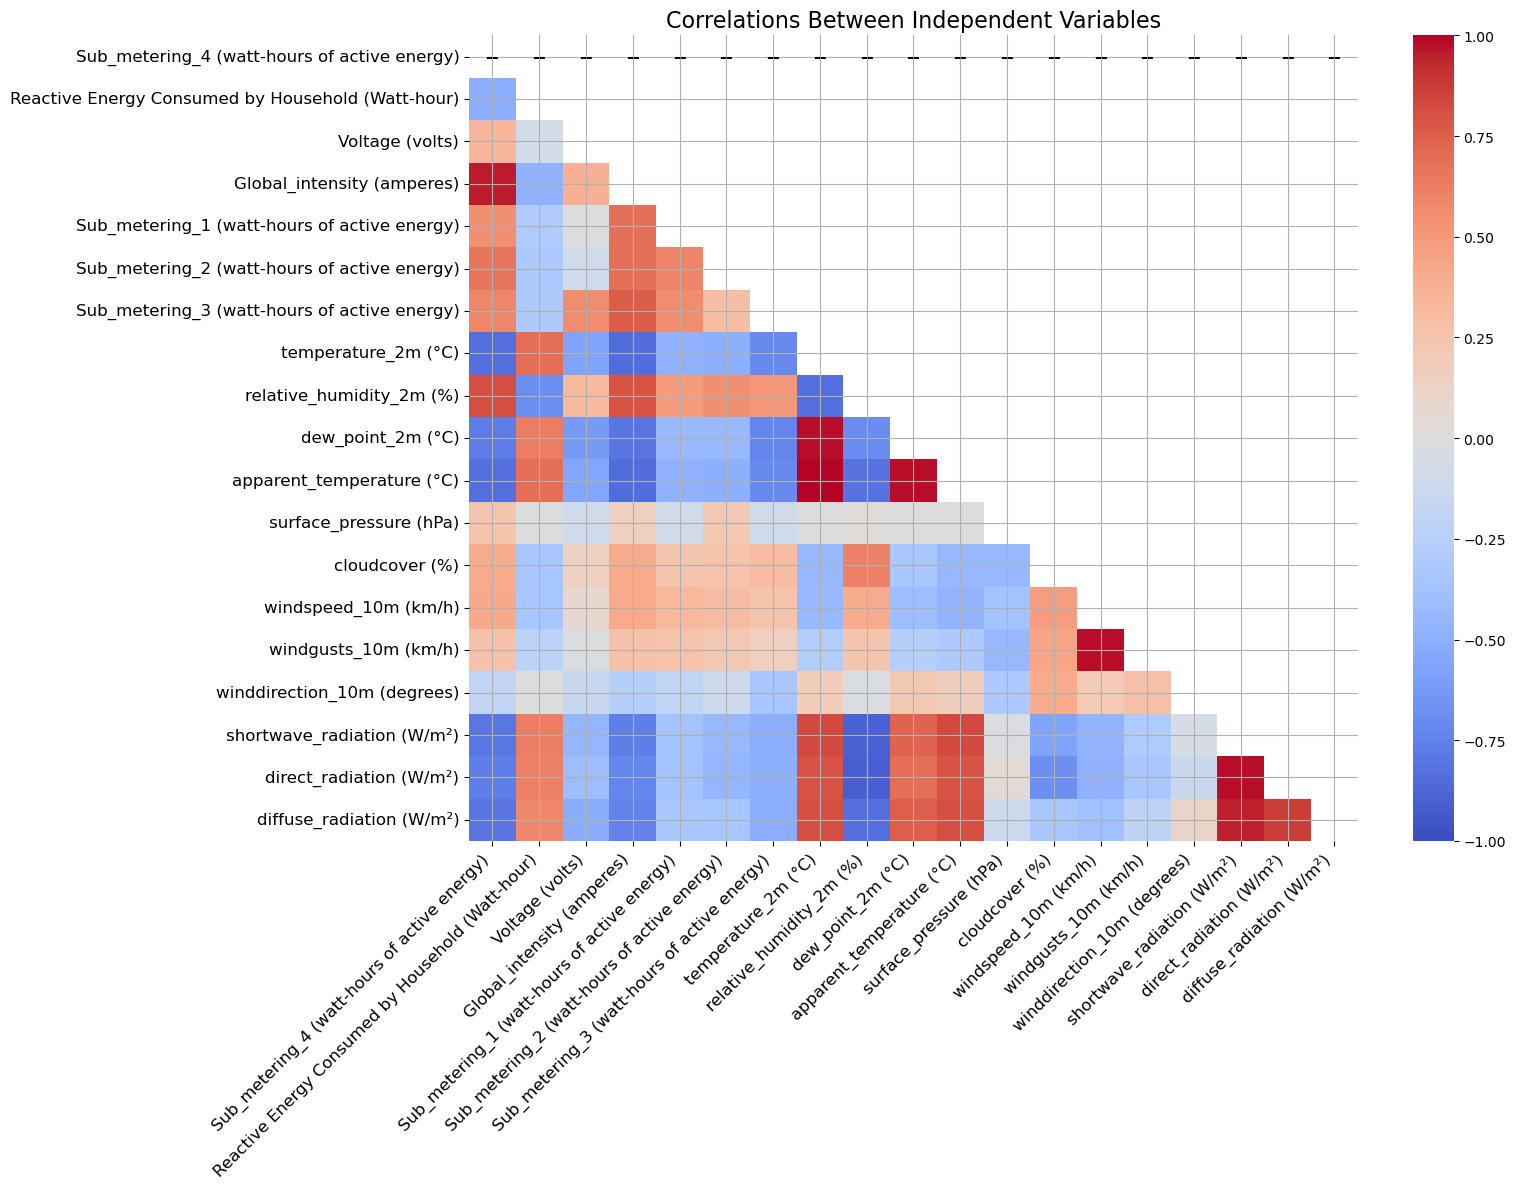

In [72]:
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_df.round(2), 
    annot=True, 
    annot_kws={"size": 12, "weight": "bold", "color": "black"},
    vmax=1, 
    vmin=-1, 
    center=0, 
    cmap="coolwarm", 
    mask=mask,
    fmt=".2f"
)
plt.title("Correlations Between Independent Variables", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()


**Note: I dont why my correlation heatmap matrix is not showing any numeric values. I tried everything, so I use a table to see the actual values**

In [73]:
X.corr().round(2)

,Sub_metering_4 (watt-hours of active energy),Reactive Energy Consumed by Household (Watt-hour),Voltage (volts),Sub_metering_1 (watt-hours of active energy),Sub_metering_2 (watt-hours of active energy),Sub_metering_3 (watt-hours of active energy),temperature_2m (°C),relative_humidity_2m (%),surface_pressure (hPa),cloudcover (%),windspeed_10m (km/h),winddirection_10m (degrees),diffuse_radiation (W/m²)
Sub_metering_4 (watt-hours of active energy),1.00,-0.51,0.35,0.55,0.66,0.59,-0.84,0.82,0.25,0.40,0.42,-0.19,-0.81
Reactive Energy Consumed by Household (Watt-hour),-0.51,1.00,-0.08,-0.29,-0.32,-0.31,0.69,-0.69,-0.01,-0.35,-0.35,-0.00,0.58
Voltage (volts),0.35,-0.08,1.00,-0.01,-0.10,0.56,-0.57,0.32,-0.10,0.15,0.08,-0.15,-0.52
Sub_metering_1 (watt-hours of active energy),0.55,-0.29,-0.01,1.00,0.60,0.56,-0.48,0.49,-0.09,0.25,0.33,-0.20,-0.33
Sub_metering_2 (watt-hours of active energy),0.66,-0.32,-0.10,0.60,1.00,0.29,-0.50,0.55,0.22,0.26,0.30,-0.11,-0.35
Sub_metering_3 (watt-hours of active energy),0.59,-0.31,0.56,0.56,0.29,1.00,-0.71,0.51,-0.10,0.31,0.25,-0.35,-0.51
temperature_2m (°C),-0.84,0.69,-0.57,-0.48,-0.50,-0.71,1.00,-0.83,-0.01,-0.44,-0.43,0.18,0.82
relative_humidity_2m (%),0.82,-0.69,0.32,0.49,0.55,0.51,-0.83,1.00,0.02,0.61,0.40,-0.03,-0.83
surface_pressure (hPa),0.25,-0.01,-0.10,-0.09,0.22,-0.10,-0.01,0.02,1.00,-0.44,-0.37,-0.32,-0.12
cloudcover (%),0.40,-0.35,0.15,0.25,0.26,0.31,-0.44,0.61,-0.44,1.00,0.48,0.40,-0.34


I will define the train and test sets based on the earlier defined dates_train and dates_test for daily data


In [74]:
# Create X_train and X_test from X using the same cutoff logic as before
X_train = X.loc[dates_train]
X_test = X.loc[dates_test]

In [75]:
X_test.head()

,Sub_metering_4 (watt-hours of active energy),Reactive Energy Consumed by Household (Watt-hour),Voltage (volts),Sub_metering_1 (watt-hours of active energy),Sub_metering_2 (watt-hours of active energy),Sub_metering_3 (watt-hours of active energy),temperature_2m (°C),relative_humidity_2m (%),surface_pressure (hPa),cloudcover (%),windspeed_10m (km/h),winddirection_10m (degrees),diffuse_radiation (W/m²)
Datetime,,,,,,,,,,,,,
2010-01-01,11.643089,2.086323,243.455510,1.298200,1.362789,9.538004,0.377776,85.044783,1004.682451,76.546685,11.114993,173.977681,22.802967
2010-02-01,10.168075,1.707351,242.348111,1.221985,1.329183,10.211667,3.371565,80.471206,993.288873,79.196160,15.988025,167.217636,39.263852
2010-03-01,8.971096,2.084247,241.993211,0.823434,1.428484,7.611574,6.090126,71.280681,1006.384237,67.692430,14.867392,167.933579,61.269888
2010-04-01,7.612963,2.080848,241.782798,0.884187,0.844371,7.780064,10.259553,68.717643,1007.753289,52.417401,13.068780,136.224137,69.062972
2010-05-01,7.835420,2.036416,240.369171,1.077690,1.173324,8.168306,12.391949,68.148107,1004.779938,64.297257,12.874001,168.308419,90.424834


In [76]:
y_train = y.loc[dates_train].dropna()
y_test = y.loc[dates_test].dropna()

In [77]:
# Fit
linreg_features = LinearRegression()
linreg_features.fit(X_train, y_train)

# Predict
linreg_features_pred_train = linreg_features.predict(X_train)
linreg_features_pred_test = linreg_features.predict(X_test)

In [78]:
# Evaluate

summary_df.loc['linreg_features'] = [
    mean_absolute_error(y_train, linreg_features_pred_train),
    mean_absolute_error(y_test, linreg_features_pred_test),
    mean_absolute_percentage_error(y_train, linreg_features_pred_train),
    mean_absolute_percentage_error(y_test, linreg_features_pred_test)
]

summary_df

,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE
Mean,4.034347e+00,3.101882e+00,2.922166e-01,2.158319e-01
linreg,4.077902e+00,3.336767e+00,2.946289e-01,2.017694e-01
linreg_ohe,1.315639e+00,1.717609e+00,9.581909e-02,1.047659e-01
linreg_features,2.021206e-14,1.986290e-14,1.224942e-15,1.145575e-15


In [79]:
# Original time series
#Plotting the model performance
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=power_df_monthly.index,
    y=power_df_monthly['Energy Consumed by Household (Watt-hour)'],
    mode='lines',
    name='data',
    line=dict(color='grey')
))

# Train predictions
fig.add_trace(go.Scatter(
    x=dates_train,
    y=linreg_features_pred_train,
    mode='lines',
    name='train',
    line=dict(color='green')
))

# Test predictions
fig.add_trace(go.Scatter(
    x=dates_test,
    y=linreg_features_pred_test,
    mode='lines',
    name='test',
    line=dict(color='black', dash='dash')
))

fig.update_layout(
    title='Linear Regression with DataSet Features Model Performance',
    yaxis_title='Watt-hour',
    xaxis_title='Date',
    legend_title='Legend'
)

fig.show()

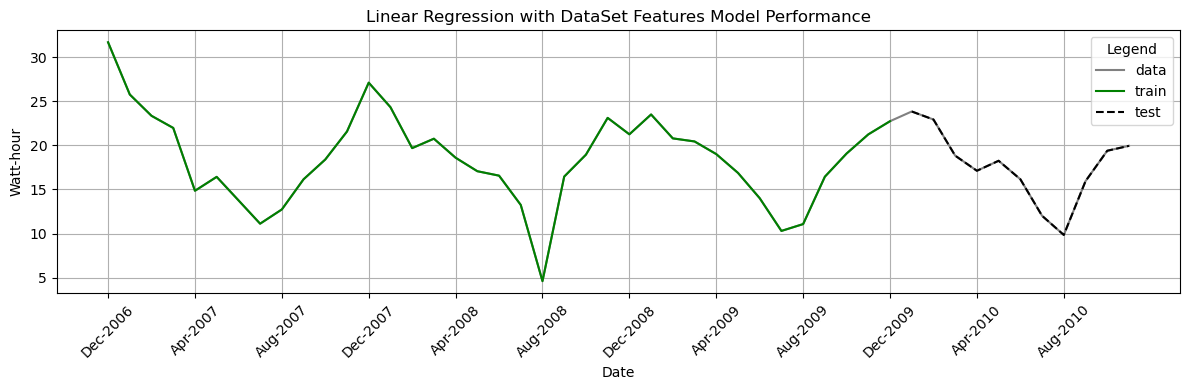

In [80]:
#Plotting the model performance
plt.figure(figsize=(12, 4))

# Original time series
plt.plot(power_df_monthly.index, power_df_monthly['Energy Consumed by Household (Watt-hour)'], color='grey', label='data')

# Train predictions
plt.plot(dates_train, linreg_features_pred_train, color='green', label='train')

# Test predictions
plt.plot(dates_test, linreg_features_pred_test, color='black', linestyle='--', label='test')

plt.title('Linear Regression with DataSet Features Model Performance')
plt.ylabel('Watt-hour')
plt.xlabel('Date')
plt.legend(title='Legend')

# Format x-axis as month-year and reduce number of ticks
labels = pd.to_datetime(power_df_monthly.index).strftime('%b-%Y')
step = max(1, len(labels) // 10)
plt.xticks(ticks=range(0, len(labels), step), labels=labels[::step], rotation=45)

plt.tight_layout()
plt.show()


In [81]:
summary_df

,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE
Mean,4.034347e+00,3.101882e+00,2.922166e-01,2.158319e-01
linreg,4.077902e+00,3.336767e+00,2.946289e-01,2.017694e-01
linreg_ohe,1.315639e+00,1.717609e+00,9.581909e-02,1.047659e-01
linreg_features,2.021206e-14,1.986290e-14,1.224942e-15,1.145575e-15


The summary_df now contains the performance metrics for all models, including the mean model, linear regression, linear regression with one-hot encoding, and linear regression with dataset features.

The linreg_features model does show a very significant improvement in performance metrics, especially in the test set, indicating that the additional features have helped the model generalize better to unseen data, however this might also be due to the features that represent this model.

# Sprint 3: Advanced Modelling





#  Forecasting with ARIMA Model

Next I will be looking at the ARIMA models for forecasting the energy consumption.


Let's starting by building a simple ARIMA model that includes an AR term of 1 (ie. to predict each value we will use the last 1 month).

In [82]:
# Fit
arima_111 = SARIMAX(y_train, order=(1, 1, 1)).fit(disp=0)

# Predict
arima_111_pred_train = arima_111.predict(dates_train.min(), dates_train.max())
arima_111_pred_test = arima_111.predict(dates_test.min(), dates_test.max())

In [83]:
# Evaluate

summary_df.loc['arima_111'] = [
    mean_absolute_error(y_train, arima_111_pred_train),
    mean_absolute_error(y_test, arima_111_pred_test),
    mean_absolute_percentage_error(y_train, arima_111_pred_train),
    mean_absolute_percentage_error(y_test, arima_111_pred_test)
]

summary_df

,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE
Mean,4.034347e+00,3.101882e+00,2.922166e-01,2.158319e-01
linreg,4.077902e+00,3.336767e+00,2.946289e-01,2.017694e-01
linreg_ohe,1.315639e+00,1.717609e+00,9.581909e-02,1.047659e-01
linreg_features,2.021206e-14,1.986290e-14,1.224942e-15,1.145575e-15
arima_111,3.826463e+00,5.577666e+00,2.330022e-01,3.979674e-01


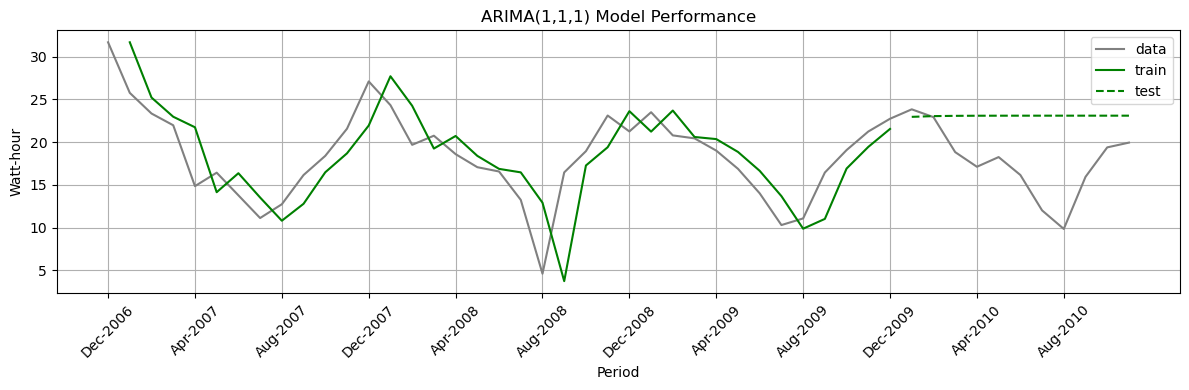

In [84]:
plt.figure()
# Original time series
plt.plot(y.index, y.values, color='grey', label="data")

# Train and test predictions
plt.plot(dates_train[1:], arima_111_pred_train[1:], color='green', label="train")
plt.plot(dates_test, arima_111_pred_test, color='green', ls="--", label="test")

plt.ylabel("Watt-hour")
plt.xlabel("Period")
plt.title(f"ARIMA(1,1,1) Model Performance")
plt.legend()

# Format x-axis as month-year and reduce number of ticks
labels = pd.to_datetime(y.index).strftime('%b-%Y')
step = max(1, len(labels) // 10)
plt.xticks(ticks=range(0, len(labels), step), labels=labels[::step], rotation=45)

plt.tight_layout()
plt.show()

In [85]:
import plotly.graph_objs as go

fig = go.Figure()

# Original time series
fig.add_trace(go.Scatter(
    x=y.index,
    y=y.values,
    mode='lines',
    name='data',
    line=dict(color='grey')
))

# Train predictions
fig.add_trace(go.Scatter(
    x=dates_train[1:],
    y=arima_111_pred_train[1:],
    mode='lines',
    name='train',
    line=dict(color='green')
))

# Test predictions
fig.add_trace(go.Scatter(
    x=dates_test,
    y=arima_111_pred_test,
    mode='lines',
    name='test',
    line=dict(color='green', dash='dash')
))

# Format x-axis as month-year and reduce number of ticks
labels = pd.to_datetime(y.index).strftime('%b-%Y')
step = max(1, len(labels) // 10)
fig.update_layout(
    title='ARIMA(1,1,1) Model Performance',
    yaxis_title='Watt-hour',
    xaxis_title='Period',
    legend_title='Legend',
    xaxis=dict(
        tickmode='array',
        tickvals=y.index[::step],
        ticktext=labels[::step],
        tickangle=45
    ),
    width=900,
    height=400
)

fig.show()

## Optimized ARIMA Hyperparameters

- Grid search can be performed to choose the best hyperparameters for an ARIMA model:
  - p: the number of autoregressive terms (lags) in the model
  - d: the number of times the series should be differenced
  - q: the number of previous error terms that should be included in the model

In [86]:
# setting up everything we need

# hyperparameter grids
p_range = range(1, 10)
d_range = range(1, 10)
q_range = range(1, 10)

# getting all combinations of p, d and q
pdq = list(itertools.product(p_range, d_range, q_range))

# cross validation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# empty df to keep track of model performance for each p
grid_search_scores = pd.DataFrame(columns=['CV MAE'])

In [87]:
# look through hyperparameters
for order in pdq:
    mae_scores = []
    for train_index, val_index in tscv.split(y_train):
        train_cv, val_cv = y_train.iloc[train_index], y_train.iloc[val_index]
        try:
            model = SARIMAX(train_cv, order=order).fit(disp=0)
            # Forecast for the length of validation set
            predictions = model.forecast(steps=len(val_cv))
            # Align index for comparison
            predictions.index = val_cv.index
            mae = mean_absolute_error(val_cv, predictions)
            mae_scores.append(mae)
        except Exception as e:
            # If model fails, append np.nan
            mae_scores.append(np.nan)
    # Average MAE, ignoring failed fits
    grid_search_scores.loc[f"ARIMA{order}"] = np.nanmean(mae_scores)


In [88]:
# Let's see which hyperparameter combinations achieved the lowest Mean Absolute Error

grid_search_scores.sort_values('CV MAE').head(10)

,CV MAE
"ARIMA(8, 1, 1)",3.670015
"ARIMA(9, 1, 8)",3.760833
"ARIMA(9, 1, 4)",3.771740
"ARIMA(8, 1, 2)",3.788120
"ARIMA(8, 1, 4)",3.859520
"ARIMA(8, 1, 9)",3.878551
"ARIMA(9, 1, 9)",3.882048
"ARIMA(9, 1, 2)",3.888240
"ARIMA(9, 1, 1)",3.895947
"ARIMA(7, 1, 8)",3.941475


In [89]:
# Shape of the grid search results
grid_search_scores.shape

(729, 1)

It seems that an ARIMA model with p=8, d=1 and q=1 has the lowest MAE score, let's refit the model, evaluate on the test set and plot:

In [90]:
# Fit
arima_811 = SARIMAX(train_cv, order=(8, 1, 1)).fit(disp=0)

# Predict
arima_811_pred_train = arima_811.predict(dates_train.min(), dates_train.max())
arima_811_pred_test = arima_811.predict(dates_test.min(), dates_test.max())

In [91]:
# Evaluate

summary_df.loc['arima_811'] = [
    mean_absolute_error(y_train, arima_811_pred_train),
    mean_absolute_error(y_test, arima_811_pred_test),
    mean_absolute_percentage_error(y_train, arima_811_pred_train),
    mean_absolute_percentage_error(y_test, arima_811_pred_test)
]
summary_df

,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE
Mean,4.034347e+00,3.101882e+00,2.922166e-01,2.158319e-01
linreg,4.077902e+00,3.336767e+00,2.946289e-01,2.017694e-01
linreg_ohe,1.315639e+00,1.717609e+00,9.581909e-02,1.047659e-01
linreg_features,2.021206e-14,1.986290e-14,1.224942e-15,1.145575e-15
arima_111,3.826463e+00,5.577666e+00,2.330022e-01,3.979674e-01
arima_811,3.062481e+00,1.874828e+00,1.890975e-01,1.220753e-01


In [ ]:
arima_811_pred_train

2006-12-01     0.000000
2007-01-01    31.688285
2007-02-01    25.411026
2007-03-01    22.881166
2007-04-01    21.870294
2007-05-01    15.249218
2007-06-01    18.458217
2007-07-01    15.148900
2007-08-01    14.530197
2007-09-01    20.008274
2007-10-01    20.704371
2007-11-01    23.963622
2007-12-01    26.420379
2008-01-01    25.574503
2008-02-01    24.397174
2008-03-01    21.315923
2008-04-01    18.615934
2008-05-01    15.691324
2008-06-01    15.592586
2008-07-01    14.243276
2008-08-01    11.780769
2008-09-01    12.974101
2008-10-01    19.478901
2008-11-01    21.549048
2008-12-01    23.953984
2009-01-01    23.640391
2009-02-01    19.819774
2009-03-01    23.008850
2009-04-01    21.965412
2009-05-01    15.600489
2009-06-01    12.891261
2009-07-01    12.649833
2009-08-01    13.563651
2009-09-01    14.964581
2009-10-01    17.978799
2009-11-01    19.849531
2009-12-01    21.113675
Freq: MS, Name: predicted_mean, dtype: float64

In [ ]:
import plotly.graph_objs as go

fig = go.Figure()

# Original time series
fig.add_trace(go.Scatter(
    x=y.index,
    y=y.values,
    mode='lines',
    name='data',
    line=dict(color='grey')
))

# Train predictions
fig.add_trace(go.Scatter(
    x=dates_train[1:],
    y=arima_811_pred_train[1:],
    mode='lines',
    name='train',
    line=dict(color='green')
))

# Test predictions
fig.add_trace(go.Scatter(
    x=dates_test,
    y=arima_811_pred_test,
    mode='lines',
    name='test',
    line=dict(color='green', dash='dash')
))

# Format x-axis as month-year and reduce number of ticks
labels = pd.to_datetime(y.index).strftime('%b-%Y')
step = max(1, len(labels) // 10)
fig.update_layout(
    title='ARIMA(8,1,1) Model Performance',
    yaxis_title='Watt-hour',
    xaxis_title='Period',
    legend_title='Legend',
    xaxis=dict(
        tickmode='array',
        tickvals=y.index[::step],
        ticktext=labels[::step],
        tickangle=45
    ),
    width=900,
    height=400
)

fig.show()



# XG Boost Regressor

Lets look at another model XG Boost Regressor

In [ ]:
# Prepare data for XGBoost
X_train_xgb = X_train.copy().fillna(0)
X_test_xgb = X_test.copy().fillna(0)

# Train XGBoost regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train_xgb, y_train)

# Predict
xgb_pred_train = xgb_model.predict(X_train_xgb)
xgb_pred_test = xgb_model.predict(X_test_xgb)




In [ ]:
# Evaluate
summary_df.loc['xgboost'] = [
    mean_absolute_error(y_train, xgb_pred_train),
    mean_absolute_error(y_test, xgb_pred_test),
    mean_absolute_percentage_error(y_train, xgb_pred_train),
    mean_absolute_percentage_error(y_test, xgb_pred_test)
]

In [ ]:
# Plotting the model performance
fig = go.Figure()

# Original time series
fig.add_trace(go.Scatter(
    x=y.index,
    y=y.values,
    mode='lines',
    name='data',
    line=dict(color='grey')
))

# Train predictions
fig.add_trace(go.Scatter(
    x=dates_train[1:],
    y=xgb_pred_train[1:],
    mode='lines',
    name='train',
    line=dict(color='green')
))

# Test predictions
fig.add_trace(go.Scatter(
    x=dates_test,
    y=xgb_pred_test,
    mode='lines',
    name='test',
    line=dict(color='green', dash='dash')
))

# Format x-axis as month-year and reduce number of ticks
labels = pd.to_datetime(y.index).strftime('%b-%Y')
step = max(1, len(labels) // 10)
fig.update_layout(
    title='XG Boost Model Performance',
    yaxis_title='Watt-hour',
    xaxis_title='Period',
    legend_title='Legend',
    xaxis=dict(
        tickmode='array',
        tickvals=y.index[::step],
        ticktext=labels[::step],
        tickangle=45
    ),
    width=900,
    height=400
)

fig.show()



Insights:

• 	Strong fit – Predictions for both train and test closely follow actual data.

• 	Good generalization – Minimal gap between train and test lines, indicating no overfitting.

• 	Patterns captured – Seasonal cycles and short-term fluctuations are well modeled.

• 	Minor peak underestimation – Some high-demand spikes are slightly underpredicted.


## Optimized XGBoost Hyperparameters

In [ ]:

# Hyperparameter tuning for XGBoost using GridSearchCV
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}
# Instantiate model
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train_xgb, y_train)

# Best model
best_xgb = grid_search.best_estimator_

# Predict
xgb_best_pred_train = best_xgb.predict(X_train_xgb)
xgb_best_pred_test = best_xgb.predict(X_test_xgb)

# Evaluate
summary_df.loc['xgboost_optimized'] = [
    mean_absolute_error(y_train, xgb_best_pred_train),
    mean_absolute_error(y_test, xgb_best_pred_test),
    mean_absolute_percentage_error(y_train, xgb_best_pred_train),
    mean_absolute_percentage_error(y_test, xgb_best_pred_test)
]


summary_df

,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE
Mean,4.034347e+00,3.101882e+00,2.922166e-01,2.158319e-01
linreg_ohe,1.315639e+00,1.717609e+00,9.581909e-02,1.047659e-01
linreg_features,2.021206e-14,1.986290e-14,1.224942e-15,1.145575e-15
arima_111,3.826463e+00,5.577666e+00,2.330022e-01,3.979674e-01
arima_811,3.062481e+00,1.874828e+00,1.890975e-01,1.220753e-01
xgboost,4.008336e-04,1.089735e+00,2.342684e-05,5.827498e-02
xgboost_optimized,9.082587e-04,9.997100e-01,5.873678e-05,5.559898e-02


Comments:

- xgboost_optimized has much lower errors than the base xgboost on both train and test sets.
- The train and test errors are very close for the optimized model — this is a strong indicator of good generalization.
- The MAPE values (~5.6%) mean your predictions are, on average, within about 5–6% of the actual watt-hour values — excellent accuracy for a forecasting task.


In [ ]:
fig = go.Figure()

# Original time series
fig.add_trace(go.Scatter(
    x=y.index,
    y=y.values,
    mode='lines',
    name='data',
    line=dict(color='grey')
))

# Train predictions
fig.add_trace(go.Scatter(
    x=dates_train[1:],
    y=xgb_best_pred_train[1:],
    mode='lines',
    name='train',
    line=dict(color='green')
))

# Test predictions
fig.add_trace(go.Scatter(
    x=dates_test,
    y=xgb_best_pred_test,
    mode='lines',
    name='test',
    line=dict(color='green', dash='dash')
))

# Format x-axis as month-year and reduce number of ticks
labels = pd.to_datetime(y.index).strftime('%b-%Y')
step = max(1, len(labels) // 10)
fig.update_layout(
    title='XG Boost Optimized Model Performance',
    yaxis_title='Watt-hour',
    xaxis_title='Period',
    legend_title='Legend',
    xaxis=dict(
        tickmode='array',
        tickvals=y.index[::step],
        ticktext=labels[::step],
        tickangle=45
    ),
    width=900,
    height=400
)

fig.show()



Insights:

• 	The train line closely follows the actual data, which means the model learned the patterns well.

• 	The test line also tracks the actual data quite closely, suggesting the model generalizes well and isn’t overfitting.

• 	The fluctuations in watt-hour values are captured by both train and test predictions, which is a good sign of model accuracy.

# Why Does ARIMA Underperform Compared to XGBoost?

While ARIMA is a strong contender for time series forecasting, it often performs worse than models like XGBoost—especially for complex datasets such as energy consumption—due to several key factors:

- **Feature Engineering:**  
    XGBoost (and other tree-based models) can readily incorporate a wide array of exogenous variables (e.g., temperature, humidity, time of day, day of week, holidays) as features. ARIMA's ability to handle such external predictors is limited (though ARIMAX exists, it's often less flexible). Energy consumption is heavily influenced by these external factors.

- **Non-Linear Relationships:**  
    XGBoost, being a gradient boosting algorithm, is highly effective at capturing complex, non-linear relationships and interactions between features, which are abundant in energy consumption patterns. ARIMA, fundamentally a linear model, struggles with such complexities.

- **Robustness to Outliers:**  
    Tree-based models can be more robust to outliers and noise in the data compared to ARIMA, which can be sensitive to unusual observations impacting its parameter estimation.

- **Handling of Data Structure:**  
    XGBoost can work directly with a flattened dataset where time series aspects are captured through engineered features, while ARIMA is designed for strictly sequential data and may not leverage rich feature sets as effectively.

**Summary:**  
For datasets with complex patterns, external influences, and non-linear relationships—like energy consumption—XGBoost and similar models often outperform ARIMA due to their flexibility and ability to incorporate diverse features.

# Forecasting with Facebook's Prophet


Lets look at a different modelling technique to consider Holidays and Special Events to look and Energy consumption

In [ ]:
#Lets read the data again for Prophet modeling
df=pd.read_csv(r"C:\Users\karni\OneDrive\Desktop\GitHub\BrainStation_CapstoneProject\data\power_weather_daily.csv",index_col='Datetime')
df.head()

,Energy Consumed by Household (Watt-hour),Sub_metering_4 (watt-hours of active energy),Reactive Energy Consumed by Household (Watt-hour),Voltage (volts),Global_intensity (amperes),Sub_metering_1 (watt-hours of active energy),Sub_metering_2 (watt-hours of active energy),Sub_metering_3 (watt-hours of active energy),temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),surface_pressure (hPa),cloudcover (%),windspeed_10m (km/h),windgusts_10m (km/h),winddirection_10m (degrees),shortwave_radiation (W/m²),direct_radiation (W/m²),diffuse_radiation (W/m²)
Datetime,,,,,,,,,,,,,,,,,,,,
2006-12-16,50.891246,37.073064,1.469781,236.243763,13.082828,0.000000,1.378788,12.439394,5.625303,92.825000,4.569798,2.931313,1015.163889,71.457071,9.481768,21.008965,321.304040,0.616162,0.000000,0.616162
2006-12-17,39.241435,25.657407,2.615810,240.087028,9.999028,1.411806,2.907639,9.264583,3.027049,94.708333,2.206215,0.097951,1017.579097,72.889931,7.903472,15.710764,242.601389,40.250000,16.666667,23.583333
2006-12-18,25.507245,13.214190,1.872593,241.231694,6.421667,0.738194,1.820139,9.734722,3.175417,95.688542,2.548437,0.494479,1016.970139,87.028472,6.625590,13.020660,147.589236,26.791667,6.166667,20.625000
2006-12-19,19.284653,9.119375,1.747014,241.999313,4.926389,0.582639,5.279167,4.303472,1.833819,88.668750,0.102882,-2.676146,1021.646493,34.131597,16.303924,29.688542,31.273264,49.583333,30.333333,19.250000
2006-12-20,25.760972,14.156111,1.863403,242.308063,6.467361,0.000000,1.838889,9.765972,1.220972,86.185069,-0.910590,-3.250208,1025.086319,7.914583,14.989792,27.639271,33.690625,54.875000,38.583333,16.291667


In [ ]:
#fiting Prophet model
m=Prophet()
# Adding France's national holidays for Modelling
m.add_country_holidays(country_name='FR')
# Fit the model
m.fit(df.reset_index().rename(columns={'Datetime': 'ds', 'Energy Consumed by Household (Watt-hour)': 'y'}))
# Create a dataframe to hold predictions
future = m.make_future_dataframe(periods=len(dates_test), freq='D') # Predictions made for the length of the test set



DEBUG	cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\karni\AppData\Local\Temp\tmpdk67wogi\kgeuhmce.json
DEBUG	cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\karni\AppData\Local\Temp\tmpdk67wogi\t8egm6n7.json
DEBUG	cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\karni\\anaconda3\\envs\\ml_env\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=31114', 'data', 'file=C:\\Users\\karni\\AppData\\Local\\Temp\\tmpdk67wogi\\kgeuhmce.json', 'init=C:\\Users\\karni\\AppData\\Local\\Temp\\tmpdk67wogi\\t8egm6n7.json'

In [ ]:
# Forecast future 
# Display the last few rows of the forecast
future.tail()

,ds
1448,2010-12-03
1449,2010-12-04
1450,2010-12-05
1451,2010-12-06
1452,2010-12-07


In [ ]:
#List of holidays included in the training data for France
print(m.train_holiday_names)

0      New Year's Day
1       Easter Monday
2           Labor Day
3         Victory Day
4       Ascension Day
5        National Day
6      Assumption Day
7     All Saints' Day
8       Armistice Day
9       Christmas Day
10        Whit Monday
dtype: object


The predict method will assign each row in future a predicted value which it names yhat. The forecast object here is a new dataframe that includes a column yhat with the forecast, as well as columns for components and uncertainty intervals yhat_upper and yhat_lower

In [ ]:

forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1448,2010-12-03,22.606395,16.264494,29.675013
1449,2010-12-04,25.926261,19.174423,32.130627
1450,2010-12-05,25.494203,19.089544,32.124181
1451,2010-12-06,21.871312,15.386480,27.925052
1452,2010-12-07,23.061587,17.587051,28.946446


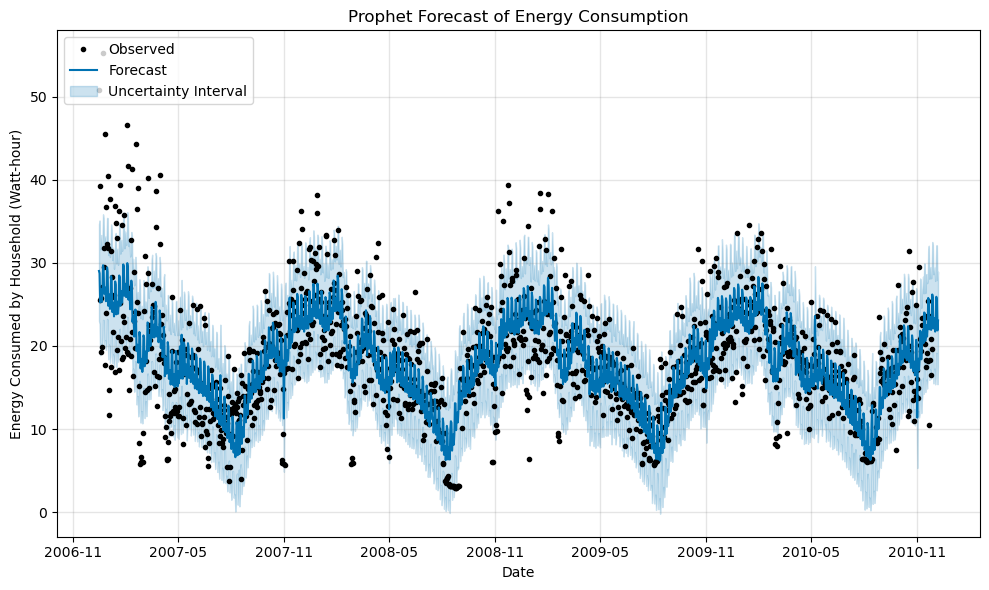

In [ ]:
# Plotting the forecast object with labels, title, and legend
fig1 = m.plot(forecast)
plt.title("Prophet Forecast of Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy Consumed by Household (Watt-hour)")
plt.tight_layout()

# Add legend for Prophet plot
plt.legend(['Observed', 'Forecast', 'Uncertainty Interval'], loc='upper left')

plt.show()


**Prophet Model Insights:**

- **Strong Fit to Historical Data:**  
    The blue forecast line closely tracks the observed black dots, indicating the model effectively captures historical energy consumption patterns.

- **Clear Seasonality:**  
    Regular peaks and troughs highlight pronounced seasonal cycles in household energy use.

- **Uncertainty Representation:**  
    The shaded region (uncertainty interval) expands in certain periods, reflecting increased model uncertainty—especially for future or volatile intervals.

- **Trend Stability:**  
    The overall trend remains steady over time, suggesting the underlying process is stable aside from seasonal fluctuations.




<Figure size 1200x400 with 0 Axes>

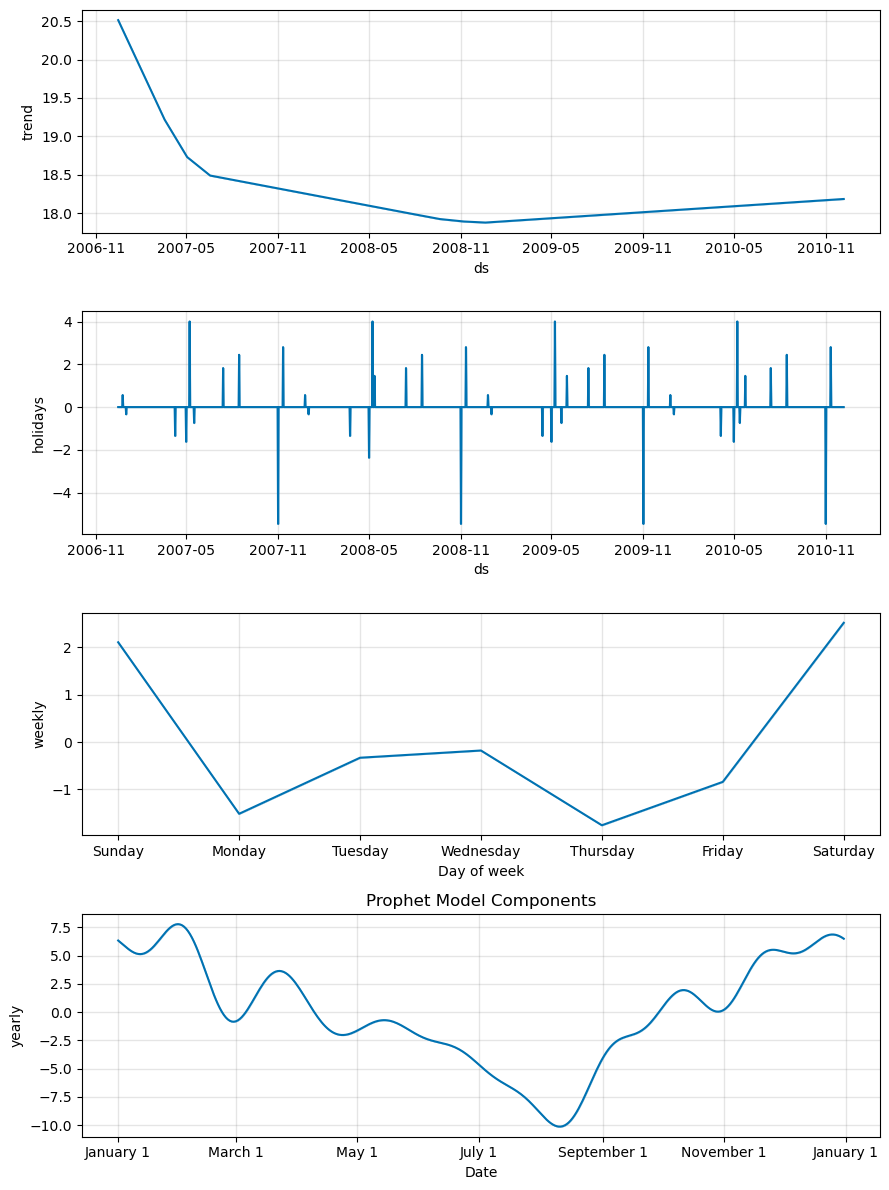

In [ ]:
plt.figure()
m.plot_components(forecast)
plt.title("Prophet Model Components")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

**Prophet Model Components Explained**

 1. **Trend (Top Panel)**
- Shows the long-term movement of the time series.
- **Late 2006 to mid-2007:** Steep drop from ~20.5 to ~18.5.
- **2008 to 2010:** Relatively flat, slow recovery.
- **Interpretation:** Baseline decreased early, then stabilized.

 2. **Holiday Effects (Second Panel)**
- Prophet adds holiday/event regressors based on country.
- **Vertical bars:** Indicate holiday impact on forecast.
- **Effect:** Some holidays increase values (positive spikes), others decrease them (negative spikes).
- **Magnitude:** Typically between -4 and +4.

 3. **Weekly Seasonality (Third Panel)**
- Shows variation across days of the week.
- **Weekends (Sat/Sun):** Higher values (positive impact).
- **Mondays/Thursdays:** Lowest values (negative impact).
- **Interpretation:** Strong weekly pattern present.

4. **Yearly Seasonality (Bottom Panel)**
- Displays recurring annual cycles.
- **Peaks:** January and February.
- **Dips:** July–September.
- **Rises:** November–December.
- **Interpretation:** Strong seasonal cycles within each year.


In [ ]:
# Calculate Prophet model performance metrics and add to summary_df

# Ensure 'ds' column in forecast and index in df are both datetime for matching
forecast['ds'] = pd.to_datetime(forecast['ds'])
df.index = pd.to_datetime(df.index)

# Filter train and test dates to start from 2007-01-01
start_date = pd.to_datetime("2007-01-01")
train_dates = pd.to_datetime(dates_train)
test_dates = pd.to_datetime(dates_test)
train_dates = train_dates[train_dates >= start_date]
test_dates = test_dates[test_dates >= start_date]

# Prophet predictions for train and test periods (match by date)
prophet_pred_train = forecast.set_index('ds').loc[train_dates, 'yhat']
prophet_pred_test = forecast.set_index('ds').loc[test_dates, 'yhat']

# True values for train and test
y_train_prophet = df.loc[train_dates]['Energy Consumed by Household (Watt-hour)']
y_test_prophet = df.loc[test_dates]['Energy Consumed by Household (Watt-hour)']

# Add Prophet metrics to summary_df
summary_df.loc['prophet'] = [
    mean_absolute_error(y_train_prophet, prophet_pred_train),
    mean_absolute_error(y_test_prophet, prophet_pred_test),
    mean_absolute_percentage_error(y_train_prophet, prophet_pred_train),
    mean_absolute_percentage_error(y_test_prophet, prophet_pred_test)
]

In [ ]:
summary_df

,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE
Mean,4.034347e+00,3.101882e+00,2.922166e-01,2.158319e-01
linreg_ohe,1.315639e+00,1.717609e+00,9.581909e-02,1.047659e-01
linreg_features,2.021206e-14,1.986290e-14,1.224942e-15,1.145575e-15
arima_111,3.826463e+00,5.577666e+00,2.330022e-01,3.979674e-01
arima_811,3.062481e+00,1.874828e+00,1.890975e-01,1.220753e-01
xgboost,4.008336e-04,1.089735e+00,2.342684e-05,5.827498e-02
xgboost_optimized,9.082587e-04,9.997100e-01,5.873678e-05,5.559898e-02
prophet,4.538755e+00,3.328523e+00,3.118428e-01,2.482262e-01


Prophet’s default forecasts show:
- Train_MAE: 4.54  Test_MAE: 3.33
- Train_MAPE: 31.2%  Test_MAPE: 24.2%
This performance is slightly worse than a simple mean baseline, indicating under‐flexibility in capturing key pattern


# Next Steps
I will give a detailed summary  from Sprint 3 for more detailed explanation in the next notebook

# Saving Results

In [ ]:
#Save summary_df to a csv file
summary_df.to_csv(r"C:\Users\karni\OneDrive\Desktop\GitHub\BrainStation_CapstoneProject\data\model_performance_summary.csv", index=True)

In [ ]:


# Create the folder if it doesn't exist
model_dir = r"C:\Users\karni\OneDrive\Desktop\GitHub\BrainStation_CapstoneProject\models"
os.makedirs(model_dir, exist_ok=True)

# Save models to pickle files in the specified folder
with open(os.path.join(model_dir, 'linreg_ohe.pkl'), 'wb') as f:
    pickle.dump(linreg_ohe, f)

with open(os.path.join(model_dir, 'linreg_features.pkl'), 'wb') as f:
    pickle.dump(linreg_features, f)

with open(os.path.join(model_dir, 'arima_111.pkl'), 'wb') as f:
    pickle.dump(arima_111, f)

with open(os.path.join(model_dir, 'arima_811.pkl'), 'wb') as f:
    pickle.dump(arima_811, f)

with open(os.path.join(model_dir, 'xgb_model.pkl'), 'wb') as f:
    pickle.dump(xgb_model, f)

with open(os.path.join(model_dir, 'best_xgb.pkl'), 'wb') as f:
    pickle.dump(best_xgb, f)

with open(os.path.join(model_dir, 'prophet_model.pkl'), 'wb') as f:
    pickle.dump(m, f)